## Bias Evaluation

### Purpose
To evaluate gender bias in the trained Naive Bayes and Logistic Regression models using Identity Term Sampling (ITS) and Gender-Selective Counterfactual Data Augmentation (GS-CDA). This technique has been adapted from [Sobhani & Delany (2024)](https://aclanthology.org/2024.gebnlp-1.10/) for Nepali. Gender bias is measured using True Positive Rate (TPR) per gender per sentiment class, and quantified using the Class Gap metric.

### Input
- `saved_models/tfidf_u.pkl` — trained unigram TF-IDF vectoriser
- `saved_models/tfidf_ub.pkl` — trained bigram TF-IDF vectoriser
- `saved_models/nb_u.pkl`, `nb_ub.pkl` — trained Naive Bayes models
- `saved_models/lr_u.pkl`, `lr_ub.pkl` — trained Logistic Regression models
- `saved_models/test_data.csv` — held-out test set from model training phase

### Output
- `gscda_test_set.csv` — gender-labelled test set with GS-CDA counterfactual pairs

### Sections
1. Identity Term Sampling (ITS) — identified and labelled sentences by gender
2. GS-CDA — generated gender-swapped counterfactual sentence pairs
3. Bias Evaluation — computed and plotted TPR and Class Gap for all four models

### Reference
Sobhani, N., & Delany, S. (2024). Towards Fairer NLP Models: Handling Gender Bias in Classification Tasks. GeBNLP @ ACL 2024.

## Identity Term Sampling

Identity Term Sampling is a method used in bias evaluation where sentences are selected based on the presence of identity-related lexical items. 

These identity terms may refer to:
- gender
- race
- religion
- nationality
- sexuality, etc.

Identity Term Sampling is relevant to this project because it helps identify and extract sentences containing gender-related lexical items such as pronouns and gendered references. This allows the study to create a gender-focused evaluation subset for analysing whether Naive Bayes and Logistic Regression models produce different sentiment predictions for male and female references.

In [1]:
import re
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [2]:
# Loading vectorisers
tfidf_u = joblib.load('saved_models/tfidf_u.pkl')
tfidf_ub = joblib.load('saved_models/tfidf_ub.pkl')

# Loading models
nb_u = joblib.load('saved_models/nb_u.pkl')
nb_ub = joblib.load('saved_models/nb_ub.pkl')
lr_u = joblib.load('saved_models/lr_u.pkl')
lr_ub = joblib.load('saved_models/lr_ub.pkl')

In [3]:
#Identifying gender identity terms

male_terms = [
    'पुरुष', 'पुरुषहरू', 'केटा', 'केटाहरू', 'बुबा', 'पिता', 'बुबाहरू', 'पिताहरू',
    'छोरा', 'छोराहरू', 'दाइ', 'भाइ', 'दाइहरू', 'भाइहरू', 'पति', 'श्रीमान',
    'पतिहरू', 'श्रीमानहरू', 'काका', 'मामा', 'काकाहरू', 'मामाहरू', 'भतिजो', 'भतिजाहरू',
    'सम्राट', 'सम्राटहरू', 'राजा', 'राजाहरू', 'राजकुमार', 'राजकुमारहरू', 'ड्युक', 'ड्युकहरू',
    'प्रभु', 'मालिक', 'प्रभुहरू', 'मालिकहरू', 'वेटर', 'वेटरहरू', 'अभिनेता', 'अभिनेताहरू',
    'देवता', 'देवताहरू', 'नायक', 'नायकहरू', 'जादूगर', 'जादूगरहरू', 'सेवक', 'सेवकहरू',
    'बाबा', 'बाबाहरू', 'स्वास्थ्य स्वयंसेवक', 'स्वास्थ्य स्वयंसेवकहरू', 'भान्जा', 'भान्जाहरू' 
]

female_terms = [
    'महिला', 'महिलाहरू', 'केटी', 'केटीहरू', 'आमा', 'माता', 'आमाहरू', 'माताहरू',
    'छोरी', 'छोरीहरू', 'दिदी', 'बहिनी', 'दिदीहरू', 'बहिनीहरू', 'पत्नी', 'श्रीमती',
    'पत्नीहरू', 'श्रीमतीहरू', 'काकी', 'माइजु', 'काकीहरू', 'माइजुहरू', 'भतिजी', 'भतिजीहरू',
    'महारानी', 'महारानीहरू', 'रानी', 'रानीहरू', 'राजकुमारी', 'राजकुमारीहरू', 'डचेस', 'डचेसहरू',
    'स्वामिनी', 'स्वामिनीहरू', 'वेट्रेस', 'वेट्रेसहरू', 'अभिनेत्री', 'अभिनेत्रीहरू', 'देवी', 'देवीहरू',
    'नायिका', 'नायिकाहरू', 'बोक्सी', 'बोक्सीहरू', 'सेविका', 'सेविकाहरू', 'युवती', 'युवतीहरू',
    'ममी', 'ममीहरू', 'स्वास्थ्य सेविका', 'स्वास्थ्य सेविकाहरू', 'भान्जी', 'भान्जीहरू' 
]

In [4]:
#Identity Term Sampling according to gendered terms on test set

def count_gender_terms(text, terms):
    count = 0
    for term in terms:
        pattern = r'(?<!\S)' + re.escape(term) + r'(?!\S)'
        matches = re.findall(pattern, text)
        count += len(matches)
    return count

def assign_gender(text):
    male_count = count_gender_terms(text, male_terms)
    female_count = count_gender_terms(text, female_terms)

    if male_count > female_count:
        return 'male'
    elif female_count > male_count:
        return 'female'
    else:
        return None

test_set = pd.read_csv('saved_models/test_data.csv')
test_set['Gender'] = test_set['Sentences'].apply(assign_gender)
bias_test_set = test_set[test_set['Gender'].notna()].copy()
bias_test_set.reset_index(drop=True, inplace = True)

In [5]:
bias_test_set['Gender'].value_counts()

Gender
female    73
male      43
Name: count, dtype: int64

## Gender-Specific Counterfactual Data Augmentation (GS-CDA)

Data augmentation is a technique used to increase the diversity of a dataset by creating modified versions of existing data while preserving its original meaning or label. In NLP, it is often used to improve model robustness and reduce bias by exposing models to varied linguistic patterns.

Gender-Specific Counterfactual Data Augmentation (GS-CDA), adapted from the bias evaluation approach discussed by Sobhani and Delany (2024) [https://aclanthology.org/2024.gebnlp-1.10/], was used to generate counterfactual sentence pairs by systematically replacing gender-related lexical terms with their counterpart forms. This method enables the study to analyse whether Naive Bayes and Logistic Regression models produce different sentiment predictions when only the gender reference in a sentence is changed while the overall semantic structure remains unchanged.

In [6]:
# Performing Data Augmentation

gender_swap = {

    # Core gender terms
    'पुरुष': 'महिला',
    'महिला': 'पुरुष',
    'पुरुषहरू': 'महिलाहरू',
    'महिलाहरू': 'पुरुषहरू',

    # Children / youth
    'केटा': 'केटी',
    'केटी': 'केटा',
    'केटाहरू': 'केटीहरू',
    'केटीहरू': 'केटाहरू',

    # Parents
    'बुबा': 'आमा',
    'आमा': 'बुबा',
    'बुबाहरू': 'आमाहरू',
    'आमाहरू': 'बुबाहरू',

    'पिता': 'माता',
    'माता': 'पिता',
    'पिताहरू': 'माताहरू',
    'माताहरू': 'पिताहरू',

    'बाबा': 'ममी',
    'ममी': 'बाबा',
    'बाबाहरू': 'ममीहरू',
    'ममीहरू': 'बाबाहरू',

    # Children
    'छोरा': 'छोरी',
    'छोरी': 'छोरा',
    'छोराहरू': 'छोरीहरू',
    'छोरीहरू': 'छोराहरू',

    # Siblings
    'दाइ': 'दिदी',
    'दिदी': 'दाइ',
    'दाइहरू': 'दिदीहरू',
    'दिदीहरू': 'दाइहरू',

    'भाइ': 'बहिनी',
    'बहिनी': 'भाइ',
    'भाइहरू': 'बहिनीहरू',
    'बहिनीहरू': 'भाइहरू',

    # Spouses
    'पति': 'पत्नी',
    'पत्नी': 'पति',
    'पतिहरू': 'पत्नीहरू',
    'पत्नीहरू': 'पतिहरू',

    'श्रीमान': 'श्रीमती',
    'श्रीमती': 'श्रीमान',
    'श्रीमानहरू': 'श्रीमतीहरू',
    'श्रीमतीहरू': 'श्रीमानहरू',

    # Extended family
    'काका': 'काकी',
    'काकी': 'काका',
    'काकाहरू': 'काकीहरू',
    'काकीहरू': 'काकाहरू',

    'मामा': 'माइजु',
    'माइजु': 'मामा',
    'मामाहरू': 'माइजुहरू',
    'माइजुहरू': 'मामाहरू',

    'भतिजो': 'भतिजी',
    'भतिजी': 'भतिजो',
    'भतिजाहरू': 'भतिजीहरू',
    'भतिजीहरू': 'भतिजाहरू',
    'भान्जा' : 'भान्जी',
    'भान्जाहरू': 'भान्जीहरू',
    

    # Royal / nobility
    'सम्राट': 'महारानी',
    'महारानी': 'सम्राट',
    'सम्राटहरू': 'महारानीहरू',
    'महारानीहरू': 'सम्राटहरू',

    'राजा': 'रानी',
    'रानी': 'राजा',
    'राजाहरू': 'रानीहरू',
    'रानीहरू': 'राजाहरू',

    'राजकुमार': 'राजकुमारी',
    'राजकुमारी': 'राजकुमार',
    'राजकुमारहरू': 'राजकुमारीहरू',
    'राजकुमारीहरू': 'राजकुमारहरू',

    'ड्युक': 'डचेस',
    'डचेस': 'ड्युक',
    'ड्युकहरू': 'डचेसहरू',
    'डचेसहरू': 'ड्युकहरू',

    # Authority / social hierarchy
    'प्रभु': 'स्वामिनी',
    'स्वामिनी': 'प्रभु',
    'प्रभुहरू': 'स्वामिनीहरू',
    'स्वामिनीहरू': 'प्रभुहरू',

    'मालिक': 'स्वामिनी',
    'स्वामिनी': 'मालिक',
    'मालिकहरू': 'स्वामिनीहरू',
    'स्वामिनीहरू': 'मालिकहरू',

    # Service professions
    'वेटर': 'वेट्रेस',
    'वेट्रेस': 'वेटर',
    'वेटरहरू': 'वेट्रेसहरू',
    'वेट्रेसहरू': 'वेटरहरू',

    'अभिनेता': 'अभिनेत्री',
    'अभिनेत्री': 'अभिनेता',
    'अभिनेताहरू': 'अभिनेत्रीहरू',
    'अभिनेत्रीहरू': 'अभिनेताहरू',

    'सेवक': 'सेविका',
    'सेविका': 'सेवक',
    'सेवकहरू': 'सेविकाहरू',
    'सेविकाहरू': 'सेवकहरू',

    # Religious / mythical
    'देवता': 'देवी',
    'देवी': 'देवता',
    'देवताहरू': 'देवीहरू',
    'देवीहरू': 'देवताहरू',

    'जादूगर': 'बोक्सी',
    'बोक्सी': 'जादूगर',
    'जादूगरहरू': 'बोक्सीहरू',
    'बोक्सीहरू': 'जादूगरहरू',

    # Heroic roles
    'नायक': 'नायिका',
    'नायिका': 'नायक',
    'नायकहरू': 'नायिकाहरू',
    'नायिकाहरू': 'नायकहरू',

    # Informal social references
    'मान्छे': 'युवती',
    'युवती': 'मान्छे',
    'मान्छेहरू': 'युवतीहरू',
    'युवतीहरू': 'मान्छेहरू',

    # COVID / healthcare discourse
    'स्वास्थ्य स्वयंसेवक': 'स्वास्थ्य सेविका',
    'स्वास्थ्य सेविका': 'स्वास्थ्य स्वयंसेवक',
    'स्वास्थ्य स्वयंसेवकहरू': 'स्वास्थ्य सेविकाहरू',
    'स्वास्थ्य सेविकाहरू': 'स्वास्थ्य स्वयंसेवकहरू'
}

def generate_gs_cda(text):
    words = text.split()
    swapped = []
    for w in words:
        swapped.append(gender_swap.get(w, w))
    return " ".join(swapped)

bias_test_set['GS-CDA Data'] = bias_test_set['Sentences'].apply(generate_gs_cda)
bias_test_set['GS-CDA Gender'] = bias_test_set['GS-CDA Data'].apply(assign_gender)

In [7]:
bias_test_set = bias_test_set.reset_index(drop=True)

In [8]:
bias_test_set['Gender'].value_counts()

Gender
female    73
male      43
Name: count, dtype: int64

In [9]:
bias_test_set['GS-CDA Gender'].value_counts()

GS-CDA Gender
male      67
female    44
Name: count, dtype: int64

In [10]:
#Creating the combined GS-CDA test set

orig_df_its = bias_test_set[['Sentences', 'Sentiment', 'Gender']].copy()
orig_df_its['Source'] = 'Original'

gscda_df = bias_test_set[['GS-CDA Data', 'Sentiment', 'GS-CDA Gender']].copy()
gscda_df.columns = ['Sentences', 'Sentiment', 'Gender']
gscda_df['Source'] = 'GS-CDA'

gscda_test_set = pd.concat([orig_df_its, gscda_df], ignore_index=True)
gscda_test_set

,Sentences,Sentiment,Gender,Source
0,सेती प्रादेशिक अस्पताल धनगढीमा उपचाररत कञ्चनपु...,-1,male,Original
1,आज पुष्टि भएका मध्ये पुरूष महिला रहेका छन् अहि...,-1,female,Original
2,स्पेनकी राजकुमारी मारिया टेरेसाको कोरोना भाइरस...,-1,female,Original
3,हालको अध्यावधिक विवरण नेपालमा कोभिड जम्मा पुष्...,-1,male,Original
4,कोभिड कारण आफ्नो दाजुभाइलाई टीका लगाउन नपाएर आ...,-1,female,Original
...,...,...,...,...
227,अाज थप जनामा कोरोना भाइरस कोभिड संक्रमण पुष्टि...,-1,male,GS-CDA
228,भारत उत्तर प्रदेशकी मन्त्री कमला राजा वरुणको क...,-1,male,GS-CDA
229,आज नवरात्रीको तेस्रो दिन चन्द्रघन्टा स्वरुपा प...,1,male,GS-CDA
230,कोरोना भाइरस नेपाल कोभिड कारण पहिलो मृत्यु पुष...,-1,male,GS-CDA


In [11]:
gscda_test_set.to_csv('gscda_test_set.csv')

In [12]:
X_test_bias = gscda_test_set['Sentences']
y_test_bias = gscda_test_set['Sentiment']

#Feature Engineering of Test Set for unigram and bigram
X_test_u_bias = tfidf_u.transform(X_test_bias)
X_test_ub_bias = tfidf_ub.transform(X_test_bias)

In [13]:
def compute_tpr_classgap(model, gscda_test_set):
    results = {}
    for gender in ['female', 'male']:
        subset = gscda_test_set[gscda_test_set['Gender'] == gender]
        y_true = subset['Sentiment']
        y_pred = subset['pred']
        for label in [1, -1]:
            tot_act_class = (y_true == label)
            if tot_act_class.sum() == 0:
                tpr = None
            else:
                tpr = (y_pred[tot_act_class] == label).sum() / tot_act_class.sum()
            results[(gender, label)] = tpr
    
    # Class gap: female - male
    gaps = {}
    for label in [1, -1]:
        f = results[('female', label)]
        m = results[('male', label)]
        if f is not None and m is not None:
            gaps[label] = round(f - m, 4)
            
    return results, gaps

In [14]:
from sklearn.metrics import confusion_matrix

#Bias evaluation of uni-gram NB model
y_pred_u_bias = nb_u.predict(X_test_u_bias)
gscda_test_set['pred']  = y_pred_u_bias
nb_u_tpr, nb_u_gap = compute_tpr_classgap(nb_u, gscda_test_set)

#Bias evaluation of bi-gram NB model
y_pred_ub_bias = nb_ub.predict(X_test_ub_bias)
gscda_test_set['pred']  = y_pred_ub_bias
nb_bi_tpr, nb_bi_gap = compute_tpr_classgap(nb_ub, gscda_test_set)

In [15]:
#Bias evaluation of bi-gram LR model
y_pred_lr_u_bias = lr_u.predict(X_test_u_bias)
gscda_test_set['pred']  = y_pred_lr_u_bias 
lr_u_tpr, lr_u_gap = compute_tpr_classgap(lr_u, gscda_test_set)

#Bias evaluation of bi-gram LR model
y_pred_lr_ub_bias = lr_ub.predict(X_test_ub_bias)
gscda_test_set['pred']  = y_pred_lr_ub_bias
lr_bi_tpr, lr_bi_gap = compute_tpr_classgap(lr_ub, gscda_test_set)

In [16]:
bias_data = [
    {   "Model": "Naive Bayes (Uni)",
        "Female TPR (+)": nb_u_tpr[('female', 1)],
        "Male TPR (+)": nb_u_tpr[('male', 1)],
        "Gap (+)": nb_u_gap[1],
        "Female TPR (-)": nb_u_tpr[('female', -1)],
        "Male TPR (-)": nb_u_tpr[('male', -1)],
        "Gap (-)": nb_u_gap[-1]
    },
    {
        "Model": "Naive Bayes (Bigram)",
        "Female TPR (+)": nb_bi_tpr[('female', 1)],
        "Male TPR (+)": nb_bi_tpr[('male', 1)],
        "Gap (+)": nb_bi_gap[1],
        "Female TPR (-)": nb_bi_tpr[('female', -1)],
        "Male TPR (-)": nb_bi_tpr[('male', -1)],
        "Gap (-)": nb_bi_gap[-1]
    },
    {
        "Model": "Logistic Regression (Unigram)",
        "Female TPR (+)": lr_u_tpr[('female', 1)],
        "Male TPR (+)": lr_u_tpr[('male', 1)],
        "Gap (+)": lr_u_gap[1],
        "Female TPR (-)": lr_u_tpr[('female', -1)],
        "Male TPR (-)": lr_u_tpr[('male', -1)],
        "Gap (-)": lr_u_gap[-1]
    },
    {   "Model": "Logistic Regression (Bigram)",
        "Female TPR (+)": lr_bi_tpr[('female', 1)],
        "Male TPR (+)": lr_bi_tpr[('male', 1)],
        "Gap (+)": lr_bi_gap[1],
        "Female TPR (-)": lr_bi_tpr[('female', -1)],
        "Male TPR (-)": lr_bi_tpr[('male', -1)],
        "Gap (-)": lr_bi_gap[-1]
    }
]

bias_score = pd.DataFrame(bias_data)
bias_score

,Model,Female TPR (+),Male TPR (+),Gap (+),Female TPR (-),Male TPR (-),Gap (-)
0,Naive Bayes (Uni),0.826923,0.843137,-0.0162,0.738462,0.745763,-0.0073
1,Naive Bayes (Bigram),0.865385,0.901961,-0.0366,0.784615,0.779661,0.0050
2,Logistic Regression (Unigram),0.807692,0.823529,-0.0158,0.846154,0.813559,0.0326
3,Logistic Regression (Bigram),0.846154,0.862745,-0.0166,0.892308,0.881356,0.0110


## Bias evaluation: 

In [17]:
x = range(len(bias_score))

models = bias_score['Model']

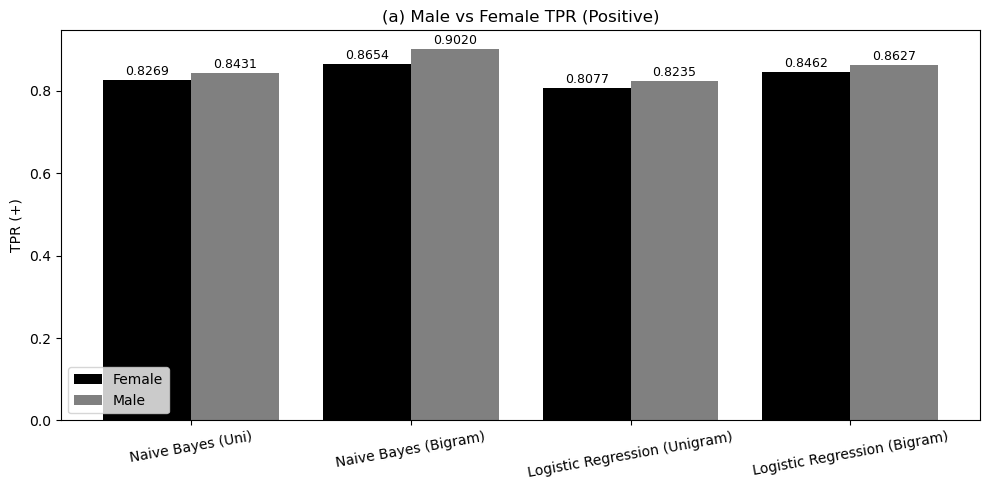

In [35]:
# Graph 1: Male vs Female TPR (Positive)

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x, bias_score['Female TPR (+)'], width=0.4, label='Female', color = '#000000')
bars2 = ax.bar([i + 0.4 for i in x], bias_score['Male TPR (+)'], width=0.4, label='Male', color = '#808080')

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,   
        bar.get_height() + 0.005,             
        f'{bar.get_height():.4f}',            
        ha='center', va='bottom', fontsize=9
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(models, rotation=10)
ax.set_ylabel('TPR (+)')
ax.set_title('(a) Male vs Female TPR (Positive)')
ax.legend()

plt.tight_layout()
plt.show()

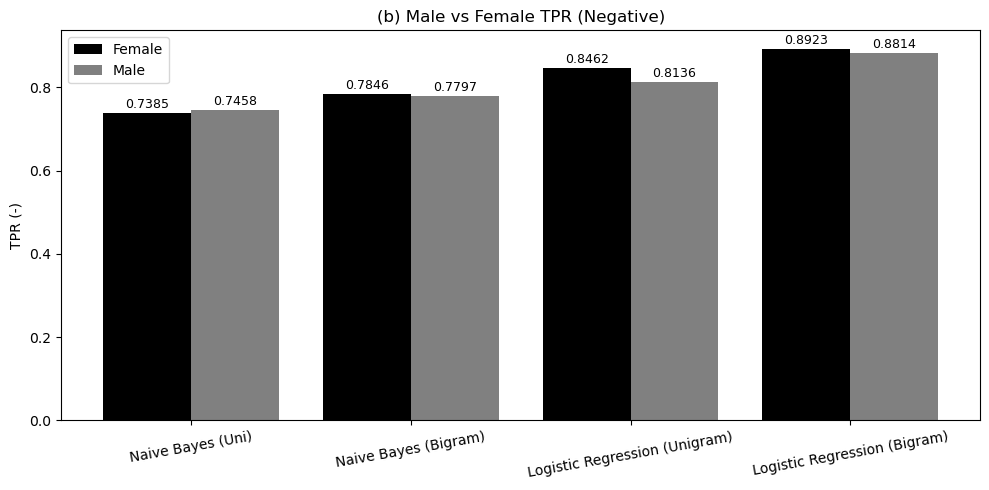

In [37]:
# Graph 2: Male vs Female TPR (Negative)

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x, bias_score['Female TPR (-)'], width=0.4, label='Female', color = '#000000')
bars2 = ax.bar([i + 0.4 for i in x], bias_score['Male TPR (-)'], width=0.4, label='Male', color = '#808080')

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom', fontsize=9
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(models, rotation=10)
ax.set_ylabel('TPR (-)')
ax.set_title('(b) Male vs Female TPR (Negative)')
ax.legend()

plt.tight_layout()
plt.show()

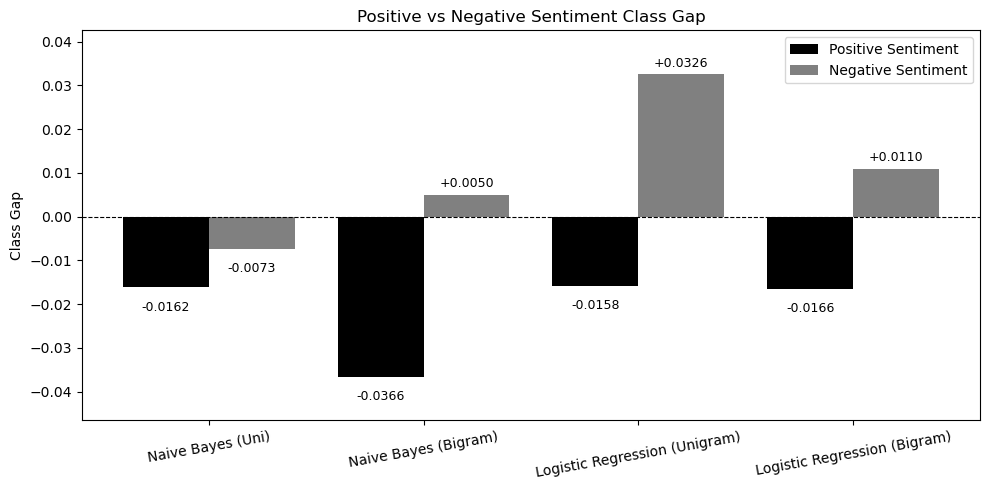

In [34]:
# Graph 3: Class Gap (Positive vs Negative)

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(bias_score))

bars1 = ax.bar(x, bias_score['Gap (+)'], width=0.4, label='Positive Sentiment', color = '#000000')
bars2 = ax.bar([i + 0.4 for i in x], bias_score['Gap (-)'], width=0.4, label='Negative Sentiment', color = '#808080')

min_gap = min(bias_score['Gap (+)'].min(),
              bias_score['Gap (-)'].min())

max_gap = max(bias_score['Gap (+)'].max(),
              bias_score['Gap (-)'].max())

ax.set_ylim(min_gap - 0.01, max_gap + 0.01)

# For gap bars: label above if positive, below if negative
for bar in bars1:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.001 if h >= 0 else h - 0.003,   
        f'{h:+.4f}',                           
        ha='center',
        va='bottom' if h >= 0 else 'top',
        fontsize=9
    )

for bar in bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.001 if h >= 0 else h - 0.003,
        f'{h:+.4f}',
        ha='center',
        va='bottom' if h >= 0 else 'top',
        fontsize=9
    )

ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(bias_score['Model'], rotation=10)
ax.set_ylabel('Class Gap')
ax.set_title('Positive vs Negative Sentiment Class Gap')
ax.axhline(y=0, linestyle='--', color='black', linewidth=0.8)
ax.legend()

plt.tight_layout()
plt.show()